<!-- Badges: -->

<!-- Title: -->
<div align="center">
  <h1><b> Entanglement </b></h1>
  <h2> Quantum Circuit Theory and Implementations </h2>
</div>
<br>

<b>Author:</b> <a target="_blank" href="https://github.com/camponogaraviera">Lucas Camponogara Viera</a>

<div align='center'>
<table class="tfo-notebook-buttons" align="head">
  <td>
    <a target="_blank" href="https://github.com/QuCAI-Lab/quantum-circuit-theory"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" /></a>
  </td>
</table>
</div>

# Table of Contents

- Multipartite Entangled States
- EPR Hypothesis
- CHSH Inequality
- Bell States 
    - The four maximally entangled states
    - Global state measurement 
    - Partial Trace
- Bell Measurement
    - Definition 
    - Application in Teleportation
    - Application in Superdene Coding
- Entanglement Swapping
- Entanglement Monogamy
    - Contrast with the multipartite GHZ entangled state
        - GHZ-like State 
    - Contrast with the multipartite W entangled state
    - Connection with the no-cloning theorem and QKD
- DI-QKD vs MDI-QKD

# &nbsp; <img valign="middle" height="45px" src="https://img.icons8.com/python" width="45" hspace="0px" vspace="0px"> Importing modules

In [20]:
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit import QuantumCircuit, assemble, Aer, execute, assemble
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# If you get hit by the error "No module named watermark", run this cell twice!

#%load_ext watermark
%reload_ext watermark
%watermark -a 'LucasCamponogaraViera' -gu 'QuCAI-Lab' -ws 'https://github.com/QuCAI-Lab/quantum-circuit-theory' -w -u -d -v -m -iv

Author: LucasCamponogaraViera

Github username: QuCAI-Lab

Website: https://github.com/QuCAI-Lab/quantum-circuit-theory

Last updated: 2024-12-19

Python implementation: CPython
Python version       : 3.11.2
IPython version      : 8.28.0

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-49-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

matplotlib: 3.6.2

Watermark: 2.3.1



# Multipartite Entangled States

An entangled state is a special kind of quantum superposition state, so it is reasonable to write the global entangled state vector of a composite system using the superposition principle. Let $\mathcal{H}_{d}=\otimes_{s=1}^N \mathcal{H}_s^{d_s}=\mathcal{H}_1^{d_1} \otimes \mathcal{H}_2^{d_2} \otimes \cdots \otimes \mathcal{H}_N^{d_N}$ denote the composite Hilbert space of a multipartite quantum system with $N$ qudits, where qudit $s$ written in an orthonormal basis set $\{|j_s\rangle \}_{j_s=1}^{d_s}$. From the superposition principle, the $N$-qudit `global entangled state vector` of the multipartite system can be written in the form:

\begin{align}
|\psi_{1\cdots N}^{entg}\rangle_{Nqd} = \sum_{j_1,\cdots,j_N=1}^{d_1\cdots d_N} c_{j_1\cdots j_N} |j_1\rangle_{1} \otimes \cdots \otimes |j_N\rangle_{N}.
\end{align}

In general, a quantum system represented by a state vector $|\psi\rangle$ is entangled if and only if it is not a product state (separable state) of its subsystems. Consequently, an entangled state is one to which it is impossible to assign a single coherent state vector to any of its subsystems, i.e., there is an intrinsic classical ignorance regarding the state preparation of its subsystems. This inability to write the subsystem of a composite system as a state vector spurred up one of the motivations that led to the development of a quantity known as the density operator.

Consider the particular case of a bipartite system with some set of orthonormal basis $\{|j_1\rangle\}_{j_1=1}^{d_1}$ $\in \mathcal{H}_1$ of subsystem $s$$=$$1$, and $\{|j_2\rangle\}_{j_2=1}^{d_2}$ $\in \mathcal{H}_2$ of subsystem $s$$=$$2$. One can always write the bipartite global state $|\psi_{12}\rangle \in$ $\mathcal{H}_1 \otimes \mathcal{H}_2$ of the composite system in the form:

\begin{eqnarray}
|\psi_{12}^{entg}\rangle_{2qd} = \sum_{j_1=1}^{d_1}\sum_{j_2=1}^{d_2} c_{j_1j_2} |j_1\rangle_{1} \otimes |j_2\rangle_{2},
\end{eqnarray}

with $c_{j_1j_2}= \langle j_1| \otimes \langle j_2|\psi_{12}\rangle$ (we momentarily drop the subscripts to avoid notation overload).

The above global state is separable if and only if the state of its subsystems can be written as state vectors of the form:

\begin{eqnarray}
|\psi_1\rangle_{1qd} = \sum_{j_1=1}^{d_1} c_{j_1} |j_1\rangle_{1},
\end{eqnarray}

and 

\begin{eqnarray}
|\psi_2\rangle_{1qd} = \sum_{j_2=1}^{d_2} c_{j_2} |j_2\rangle_{2},
\end{eqnarray} 

with $c_{j_1j_2}=c_{j_1} c_{j_2}$. 

Otherwise, the global state is entangled (not separable) and one cannot write it as a tensor product of the state vectors of its subsystems. Special bipartite entangled states of $2$-level subsystems ($d_1=d_2=2$) are the following four maximally entangled two-qubit Bell states \cite{Bell}\cite{Braunstein}, commonly known as EPR states. In the canonical basis and within the state vector formalism, they write:

\begin{align}
|\psi_{12}^{Bell \pm}\rangle &\doteq \frac{1}{\sqrt{2}} \bigg( |0\rangle_{1} \otimes |1\rangle_{2} \pm |1\rangle_{1} \otimes |0\rangle_{2} \bigg) \\
&\doteq \frac{1}{\sqrt{2}}\bigg(|01\rangle_{12} \pm |10\rangle_{12}  \bigg),
\end{align}
and
\begin{align}
|\phi_{12}^{Bell\pm}\rangle &\doteq \frac{1}{\sqrt{2}} \bigg( |0\rangle_{1} \otimes |0\rangle_{2} \pm |1\rangle_{1} \otimes |1\rangle_{2} \bigg) \\
&\doteq \frac{1}{\sqrt{2}}\bigg(|00\rangle_{12} \pm |11\rangle_{12}  \bigg).
\end{align}

Here, $|\psi_{12}^{Bell -}\rangle$ is termed a singlet state, and $|\psi_{12}^{Bell +}\rangle$ a triplet state. Explicitly, for the singlet state:

\begin{align}
    |\psi_{12}^{Bell -}\rangle &\doteq  \frac{1}{\sqrt{2}} \Bigg\{ \begin{pmatrix} 1 \\ 0 \end{pmatrix}_1 \otimes \begin{pmatrix} 0 \\ 1 \end{pmatrix}_2 - \begin{pmatrix} 0 \\ 1 \end{pmatrix}_1 \otimes \begin{pmatrix} 1 \\ 0 \end{pmatrix}_2 \Bigg\} \\
    &=\frac{1}{\sqrt{8}} \Bigg\{ \begin{pmatrix} 1 \\ i \end{pmatrix}_1 \otimes \begin{pmatrix} i \\ 1 \end{pmatrix}_2 - \begin{pmatrix} i \\ 1 \end{pmatrix}_1 \otimes \begin{pmatrix} 1 \\ i \end{pmatrix}_2 \Bigg\}. 
\end{align}

Any attempt to write an entangled state as a tensor product of well-defined coherent state vectors yields an absurd. To demonstrate that we equate the Bell state $|\phi_{12}^{Bell +}\rangle$ to a tensor product of state vectors $|\psi_1\rangle\doteq\alpha_1|0\rangle+\beta_1 |1\rangle$ and $|\psi_2\rangle\doteq\alpha_2|0\rangle+\beta_2 |1\rangle$ from subsystems $s=1$ and $s=2$, respectively, as follows:

\begin{align}
    |\psi_{12}^{sep}\rangle &= |\psi_1\rangle \otimes |\psi_2\rangle \\
    &=\alpha_1\alpha_2 |00\rangle+ \alpha_1\beta_2 |01\rangle \\
    &+ \beta_1\alpha_2 |10\rangle+ \beta_1\beta_2 |11\rangle \\
    &= \frac{1}{\sqrt{2}}\left( |00\rangle + |11\rangle  \right) \\
    &\implies \alpha_1\alpha_2=\beta_1\beta_2=\frac{1}{\sqrt{2}} \\
    &\implies \alpha_1\beta_2 \wedge \beta_1\alpha_2 \neq 0,
\end{align}

which is absurd since the last coefficients must vanish. Therefore, the global state of the composite system is said to be entangled. It is worth mentioning that, while the state preparation of their subsystems is unknown for Bell entangled states, the global state of the entangled system is completely known. Global states that are completely known are commonly referred to as pure states (whether entangled or not). In section \autoref{sec:densityformalism}, within the density operator formalism, we demonstrate the criteria used to decide whether a generic qudit state is pure or mixed. In \autoref{sec:puritysec}, we explore the characteristic of maximally entangled pure states whose subsystems are described by maximally mixed reduced density operators.

Moreover, it is possible to go from one Bell state to another via simple local operations, which do not change the degree of entanglement. For instance: 

$$\sigma_x |\phi_{12}^{Bell +}\rangle=|\psi_{12}^{Bell +}\rangle,$$

where $\sigma_x$ is the Pauli-x matrix. However, there are multipartite entangled states that, in general, cannot be transformed into one another by stochastic local operations and classical communications (SLOCC), with the exception of tripartite states ($N$$=$$3$ qudits) in the asymptotic regime such as the 3-qubit Greenberger-Horne-Zeilinger (GHZ)-like and the W-like multipartite maximally entangled states:

\begin{align}
|GHZ\rangle_{3qb} &\doteq \frac{1}{\sqrt{2}} \left ( |000\rangle +  |111\rangle \right ), \\
|W\rangle_{3qb} &\doteq \frac{1}{\sqrt{3}} \left ( |001\rangle +  |010\rangle + |100\rangle \right).
\end{align} 

As a word of caution, entanglement cannot be created via LOCC acting on its subsystems, it can either be preserved or destroyed. 

# EPR Hypothesis

In considering Max Born's probabilistic interpretation of the wave function, Albert Einstein addressed the mechanism of the wave function collapse during discussions at the 1927 Solvay conference. Einstein's gedanken (thought experiment) considered the diffraction of a beam of a single electron passing through a pinhole. According to the principle of superposition, before the electron hits a screen, the wave function in the position space represents the superposition of all the eigenstates associated with the positions available to the electron on that screen. The act of measurement would then cause the wave function to collapse to a single eingestate of the position observable. Einstein referred to this mechanism by which the wave function is instantly updated as action at a distance. 

Einstein went further with his hypothesis that quantum mechanics was incomplete and published, among three other physicists, the so-called EPR paper in 1935. The paper devised a thought experiment considering a system of two entangled particles to assess whether a measurement in one particle would have an instantaneous effect on the other. The starting point of the EPR paper adopts the following definitions regarding the quantum mechanical theory:

- `Realism:` every element of reality in nature (the so-called observables) must be predicted within the quantum theory without causing any disturbance to the quantum system. That is, it should be possible to predict the outcome of a measurement with 100\% certainty before the measurement is even realized.
- `Self-consistency:` a quantum theory shall be able to predict and explain experimental data in a consistent manner, i.e., free of contradictions.
- `Completeness:` a complete quantum theory is such that there is a theoretical analog for every element of reality in nature.
- `Locality:` a measurement in one subsystem should not influence the outcome of a measurement in another subsystem.


Then, for two conjugate observables $\hat{A}$ and $\hat{B}$ satisfying  (e.g. spin $\hat{\sigma}_x$ and $\hat{\sigma}_z$), the EPR paper states that only one of the following two hypotheses is a correct assumption about quantum mechanics:

- $\hat{A}$ and $\hat{B}$ cannot simultaneously satisfy the criterion of realism;
- The theory of quantum mechanics is incomplete.

# CHSH Inequality

In 1964, John Bell proposed a deterministic local hidden variable model (LHVM) to assess the claims put forward by the EPR paper. Bell's approach considered a generic statistical theory (that is, not necessarily related to quantum mechanics) with notions of a probability distribution $p(\lambda)$ of a sample space $\Lambda$ with hidden variables $\lambda$. Restricting the case for a bipartite system, the model allowed the possibility of measuring variables (observables) $A_1$ and $A_2$ in subsystem $A$, and variables $B_1$ and $B_2$ in subsystem $B$ with probability outcomes $a_1, a_2$ and $b_1, b_2$, respectively, sharing the following relation:

\begin{align}
    C(\lambda) &\doteq A_1(\lambda) B_1(\lambda) + A_1(\lambda) B_2(\lambda) + A_2(\lambda) B_1(\lambda) - A_2(\lambda) B_2(\lambda),
\end{align}

where the variables take on two dichotomic measurements whose spectrum of values ranges between $\pm 1$. Then, for an ensemble of particles in a perfect entangled state (e.g. singlet state), the joint probability of the ensemble statistics yields:

\begin{align}
    p(ab|AB) \neq p(a|A)p(b|B).
\end{align}

If locality is assumed, one then has

\begin{align}
    C(\lambda) &\doteq A_1(\lambda)[B_1(\lambda)+B_2(\lambda)] + A_2(\lambda)[B_1(\lambda)-B_2(\lambda)] = \pm 2.
\end{align}

and also

\begin{align}
p(ab|AB) = \int_{\Lambda} p(a|A\lambda)p(b|B\lambda) p(\lambda)d\lambda.
\end{align}

Building on Bell's paper, and assuming locality, Clauser, Horne, Shimony, and Holt devised the following correlation inequality known as the CHSH inequality for bipartite systems:

\begin{align}
    |\langle C(\lambda) \rangle| &\doteq \bigg| \int_{\Lambda} \bigg\{A_1(\lambda)[B_1(\lambda)+B_2(\lambda)]
    + A_2(\lambda)[B_1(\lambda)-B_2(\lambda)]\bigg\}p(\lambda)d\lambda \bigg|\leq 2,
\end{align}

corresponding to a bound on any LHVM. The CHSH inequality is regarded as a more feasible inequality for an experimental test of the LHVM as an independent hypothesis from quantum formalism. To name a few, Ursin et al., in 2006, reported an experimental violation of the CHSH inequality measured by two observers separated by a distance of $144km$. Aspect et al. were the first to verify experimentally the violation of Bell's inequality. However, to ensure that the state of particle $q_2$ is instantly determined once the state of particle $q_1$ is measured, the experiment must be carried out during a time window shorter than the time taken by any possible contaminating information traveling from one particle to the other at the speed of light and which could influence the result of a measurement. The first loophole-free experiment of this kind was only carried out by Hensen et al., in 2015, reporting a violation of the CHSH inequality. The experiment consisted of spin-like particles separated by a distance of $1,280m$ setting a $4.27$-$ms$ time window during which two local events are space-like separated. The experimental evidence that certain entangled states do violate Bell's inequality confirms that locality and realism known together as local-realism cannot be simultaneously satisfied.

Theoretically, one can show the maximum violation of the CHSH inequality for the following quantum observables:
\begin{align}
    \hat{A}_1 &\doteq R\doteq\vec{r}\cdot \vec{\sigma}, \\
    \hat{A}_2 &\doteq Q\doteq\vec{q}\cdot \vec{\sigma},\\
    \hat{B}_1 &\doteq S\doteq\vec{s}\cdot \vec{\sigma},\\
    \hat{B}_2 &\doteq T\doteq\vec{t}\cdot \vec{\sigma},
\end{align}
where $\vec{r}$, $\vec{q}$, $\vec{s}$, and $\vec{t}$ are 3-dimensional real unit vectors describing the measurements performed by each parties, and $\vec{\sigma} = \sigma_x \hat{x}+  \sigma_y \hat{y} + \sigma_z \hat{z}$ is a 3-dimensional vector with the Pauli-$\sigma$ matrices defined in. One then has

\begin{align}
    \hat{c} &= R \otimes S + R \otimes T + Q \otimes S - Q \otimes T,
\end{align}

so that

\begin{align}
    \langle \hat{c} \rangle &= \langle \psi_{ab} |R \otimes S |  \psi_{ab} \rangle +
     \langle \psi_{ab} |R \otimes T |  \psi_{ab} \rangle \\&+
      \langle \psi_{ab} |Q \otimes S |  \psi_{ab} \rangle -
       \langle \psi_{ab} |Q \otimes T |  \psi_{ab} \rangle.
\end{align}

Then, using Tsirelson's inequality defined as
\begin{align*}
    4 \id_2 + [Q, R] \otimes [S, T] &\doteq \bigg(Q \otimes S + R \otimes S+R \otimes T - Q \otimes T \bigg)^2,
\end{align*}

one has

\begin{align}
    \langle \hat{c}^2 \rangle &= \langle 4 \id_2 \rangle + \langle [Q, R] \otimes [S, T] \rangle \\
    &=\langle 4 \id_2 \rangle + \langle [Q, R]  \rangle \langle [S, T] \rangle,
\end{align}

given that $\langle a + b \rangle = \langle a \rangle + \langle b \rangle$. Cauchy-Schwarz inequality then yields

\begin{align}
    |\langle [Q, R] \rangle| \leq 2 \sqrt{\langle Q^2 \rangle  \langle R^2 \rangle} =2.
\end{align}

Moreover,

\begin{align}
    \langle \hat{c}^2 \rangle -  \langle \hat{c} \rangle^2 \geq 0 \implies \langle \hat{c} \rangle \leq \sqrt{\langle \hat{c}^2 \rangle},
\end{align}

and since $\langle 4 \id_2 \rangle=\langle \psi |4\id_2 |\psi \rangle = 4 \langle \psi | \psi \rangle = 4 |\psi|^2 = 4$ one finally has:

\begin{align}
    \langle \hat{c} \rangle \leq \sqrt{4+2\cdot 2} = 2\sqrt{2}.
\end{align}

This result is known as the Tsirelson bound that violates the CHSH inequality. 

- Any entangled pure state violates Bell's inequalities.
- In the case of entangled pure states, the violation of Bell's inequalities is solely related to the presence of nonlocality.
- Not every entangled state violates Bell's inequalities. One example are mixed entangled states admitting a local model.

# Bell States (maximally entangled states)

## The four maximally entangled states

Bell states are a set of four 2-qubit maximally entangled pure states, defined as:

$$|\phi^+ \rangle = \frac{1}{\sqrt 2}(|00\rangle + |11\rangle).$$
$$|\phi^- \rangle = \frac{1}{\sqrt 2}(|00\rangle - |11\rangle).$$
$$|\psi^+ \rangle = \frac{1}{\sqrt 2}(|01\rangle + |10\rangle).$$
$$|\psi^- \rangle = \frac{1}{\sqrt 2}(|01\rangle - |10\rangle).$$

Each subsystem (1-qubit) of a Bell state, after tracing out (discarding) one of the qubits, is in a maximally mixed reduced state, i.e., a state of maximum entropy, i.e., the least amount of classical knowledge (predictability power) about the state of the system upon measurement. Mixed states should then be represented by a density operator with equal diagonal entries that represent a uniform probability distribution over states $|0\rangle$ and $|1\rangle$.

It is possible to go from one Bell state to another via simple local operations, which do not change the degree of entanglement. For instance:

$$\sigma_x |\phi^+ \rangle = |\psi^+ \rangle.$$

In [3]:
'''State |phi+>'''

def PhiPlus():
    #sim = Aer.get_backend('aer_simulator')  # Define the simulator backend.
    qc = QuantumCircuit(2)                   # Creates the circuit object.
    qc.h(0), qc.cx(0,1)                      # Add gates to the circuit.
    #qc.save_statevector()                   # Tell simulator to save the statevector.
    #qobj = assemble(qc)                     # Create a Qobj from the circuit for the simulator to run.
    #result = sim.run(qobj).result()         # Run the simulation and return the result.
    #out_state = result.get_statevector()    #
    #print(out_state)                        # Print the resulting state vector.
    print(Statevector.from_instruction(qc))
    return qc

phi_plus = PhiPlus()
phi_plus.draw()

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘

In [4]:
'''State |phi->'''

def PhiMinus():
    qc = QuantumCircuit(2) 
    qc.x(0), qc.h(0), qc.cx(0,1) 
    print(Statevector.from_instruction(qc))
    return qc

phi_minus = PhiMinus()
phi_minus.draw()

Statevector([ 0.70710678+0.j,  0.        +0.j,  0.        +0.j,
             -0.70710678+0.j],
            dims=(2, 2))


┌───┐┌───┐     
q_0: ┤ X ├┤ H ├──■──
     └───┘└───┘┌─┴─┐
q_1: ──────────┤ X ├
               └───┘

In [5]:
'''State |psi+>'''

def PsiPlus():
    qc = QuantumCircuit(2) 
    qc.h(0), qc.x(1), qc.cx(0,1) 
    print(Statevector.from_instruction(qc))
    return qc

psi_plus = PsiPlus()
psi_plus.draw()

Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))


┌───┐     
q_0: ┤ H ├──■──
     ├───┤┌─┴─┐
q_1: ┤ X ├┤ X ├
     └───┘└───┘

In [6]:
'''State |psi->'''

def PsiMinus():
    qc = QuantumCircuit(2) 
    qc.h(0), qc.x(1), qc.z(1), qc.z(0), qc.cx(0,1) 
    print(Statevector.from_instruction(qc))
    return qc

psi_minus = PsiMinus()
psi_minus.draw()

Statevector([ 0.        +0.j,  0.70710678+0.j, -0.70710678+0.j,
              0.        +0.j],
            dims=(2, 2))


┌───┐┌───┐     
q_0: ┤ H ├┤ Z ├──■──
     ├───┤├───┤┌─┴─┐
q_1: ┤ X ├┤ Z ├┤ X ├
     └───┘└───┘└───┘

## Global state measurement

- Example of how to measure the Bell state $|\phi^+ \rangle = \frac{1}{\sqrt(2)}(|00\rangle + |11\rangle)$:

In [7]:
'''State |phi+>'''

qc = QuantumCircuit(2) 
qc.h(0), qc.cx(0,1) 
qc.measure_all() # Measuring all qubits in the computational basis.
qc.draw() 

┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        └───┘┌─┴─┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├─░──╫─┤M├
             └───┘ ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1

Measurement results: {'00': 497, '11': 527}


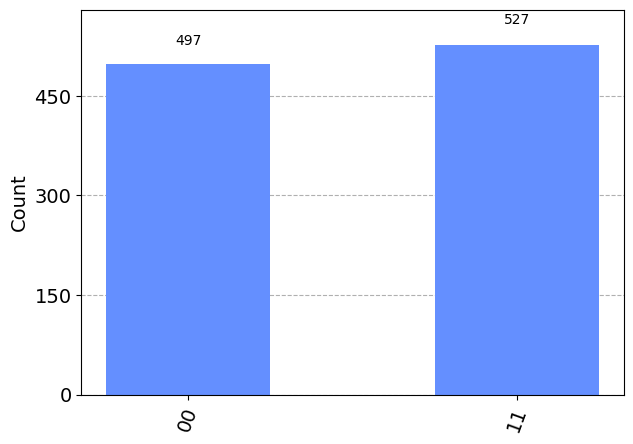

In [8]:
backend = Aer.get_backend('qasm_simulator')                       # Define the Backend for the simulator.
counts = execute(qc, backend, shots = 1024).result().get_counts() # Run the simulation and get the counts.
print("Measurement results:", counts)                             # 
plot_histogram(counts)                                            # Plot a histogram of outcomes and corresponding probabilities.

## Partial Trace

What happens to the global state of the system if only one of the subsystemns (qubits) is measured?

Consider, for instance, a bipartite quantum system whose global state is the singlet state with associated bipartite pure density operator $\rho_{ab}$. One can show that each subsystem of $\rho_{ab}$ is in a maximally mixed state. 

To demonstrate that, let us derive the reduced density operator $\rho_a$ of the first qubit in subsystem $a$, as follows:

\begin{align}
\rho_a &= tr_b(\rho_{ab}) =tr_b\left(|\psi_{ab}^{Bell -}\rangle \langle\psi_{ab}^{Bell -}|\right) \\
&=  tr_b \left\{
\left( \frac{|0_a1_b\rangle - |1_a0_b\rangle}{\sqrt{2}} \right)
\left(\frac{\langle0_a1_b| - \langle 1_a0_b|}{\sqrt{2}} \right)
\right\}
\\
&=\frac{1}{2}tr_b
\Bigg\{
|0_a1_b\rangle\langle0_a1_b|-|0_a1_b\rangle\langle1_a0_b|\\
&-|1_a0_b\rangle\langle0_a1_b|+|1_a0_b\rangle\langle1_a0_b|
\Bigg\}.
\end{align}

Using the identity $(|a\rangle \langle c|) \otimes (|b\rangle \langle d|)  = \big(|a\rangle \otimes |b\rangle\big)\big(\langle c| \otimes \langle d|\big) \equiv |ab\rangle \langle cd|$, one then has:

\begin{align}
&=\frac{1}{2}\Bigg\{tr_b(|0_a\rangle\langle0_a|\otimes|1_b\rangle\langle1_b|\\
&-tr_b(|0_a\rangle\langle1_a|\otimes|1_b\rangle\langle0_b|)\\
&-tr_b(|1_a\rangle\langle0_a|\otimes|0_b\rangle\langle1_b|)\\
&+tr_b(|1_a\rangle\langle1_a|\otimes|0_b\rangle\langle0_b|))\Bigg\}.
\end{align}

Using the identity $tr_b(|a_j\rangle \langle a_k| \otimes |b_l\rangle \langle b_m|) = |a_j \rangle \langle a_k| \cdot \langle b_m|b_l\rangle $, one then has:

\begin{align}
\rho_a&=\frac{1}{2}
\Bigg\{
|0_a\rangle \langle 0_a| \langle 1_b|1_b\rangle  - |0_a\rangle \langle 1_a| \langle 1_b|0_b\rangle \\
&- |1_a\rangle \langle 0_a| \langle 0_b|1_b\rangle + |1_a\rangle \langle 1_a| \langle 0_b|0_b\rangle
\Bigg\}\\
&=\frac{|0\rangle \langle 0|+|1\rangle \langle 1|}{2} = \frac{I_2}{2} = 
\begin{bmatrix} 
0.5 && 0  \\
0 && 0.5  
\end{bmatrix}.
\end{align}

Since $tr(\rho_a^2)=tr(\rho_b^2)=tr(\frac{I_2}{2})^2 = \frac{1}{4}tr(I_2^2)=\frac{1}{2}$, such a subsystem is in a maximally mixed state. The matrix representing such a state is dubbed an `incoherent density matrix`.

# Bell Measurement

## Definition

A Bell measurement is a joint measurement in the Bell basis of a system of two qubits. It is used to identify in which of the four Bell states the system was prepared. It can also be used to redistribute entanglement (not to be confused with entanglement swapping) within a system with more than two qubits (see the `Application in Teleportation` section).

Features:

- A Bell measurement applied to a non-entangled (separable) state will probabilistically project (encode) this state onto one of the four Bell states and thus create entanglement. Probabilistically means that it depends on the initial state.

- A Bell measurement applied to a Bell (entangled) state will project (decode) this state onto a classical state:
$$|\phi^+ \rangle \rightarrow |00\rangle.$$
$$|\phi^- \rangle \rightarrow |01\rangle.$$
$$|\psi^+ \rangle \rightarrow |10\rangle.$$
$$|\psi^- \rangle \rightarrow |11\rangle.$$

Qiskit implementation of a Bell measurement on the four Bell states:

In [9]:
# Defining the Bell measurement:

def BellMeasurement(qc):
    qc.cx(0,1), qc.h(0)
    qc.measure_all() # Measuring all qubits. A quantum computer always measures in the computational basis.
    return qc 

backend = Aer.get_backend('qasm_simulator')                       # Define the Backend for the simulator.

In [10]:
# Utility function

def GetCounts(qc):
    counts = execute(qc, backend, shots = 1024).result().get_counts() # Run the simulation and get the counts.
    print("Measurement results:", counts)                             
    return counts

In [11]:
qc = BellMeasurement(phi_plus)
qc.draw() 

┌───┐          ┌───┐ ░ ┌─┐   
   q_0: ┤ H ├──■────■──┤ H ├─░─┤M├───
        └───┘┌─┴─┐┌─┴─┐└───┘ ░ └╥┘┌─┐
   q_1: ─────┤ X ├┤ X ├──────░──╫─┤M├
             └───┘└───┘      ░  ║ └╥┘
meas: 2/════════════════════════╩══╩═
                                0  1

Measurement results: {'00': 1024}


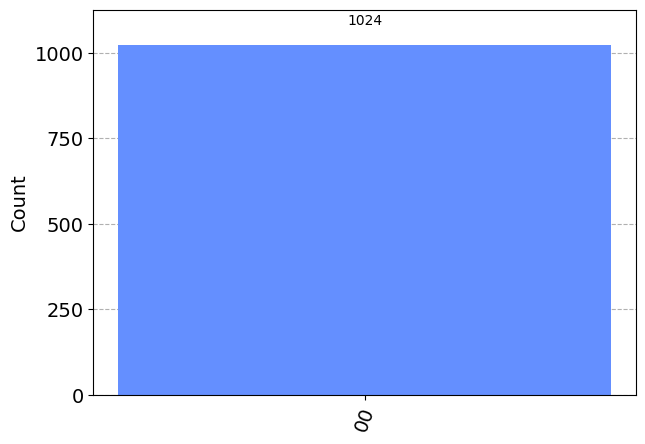

In [12]:
counts = GetCounts(qc)
plot_histogram(counts)

In [13]:
qc = BellMeasurement(phi_minus)
qc.draw() 

┌───┐┌───┐          ┌───┐ ░ ┌─┐   
   q_0: ┤ X ├┤ H ├──■────■──┤ H ├─░─┤M├───
        └───┘└───┘┌─┴─┐┌─┴─┐└───┘ ░ └╥┘┌─┐
   q_1: ──────────┤ X ├┤ X ├──────░──╫─┤M├
                  └───┘└───┘      ░  ║ └╥┘
meas: 2/═════════════════════════════╩══╩═
                                     0  1

Measurement results: {'01': 1024}


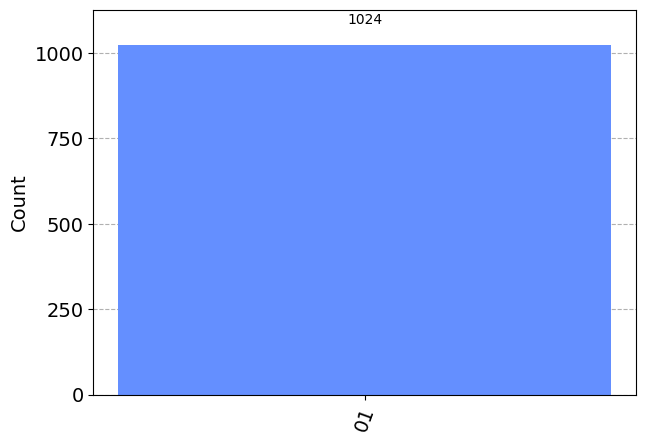

In [14]:
counts = GetCounts(qc)
plot_histogram(counts)

In [15]:
qc = BellMeasurement(psi_plus)
qc.draw() 

┌───┐          ┌───┐ ░ ┌─┐   
   q_0: ┤ H ├──■────■──┤ H ├─░─┤M├───
        ├───┤┌─┴─┐┌─┴─┐└───┘ ░ └╥┘┌─┐
   q_1: ┤ X ├┤ X ├┤ X ├──────░──╫─┤M├
        └───┘└───┘└───┘      ░  ║ └╥┘
meas: 2/════════════════════════╩══╩═
                                0  1

Measurement results: {'10': 1024}


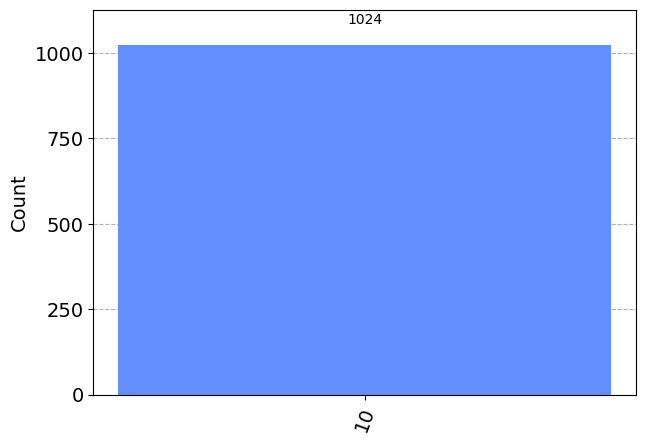

In [16]:
counts = GetCounts(qc)
plot_histogram(counts)

In [17]:
qc = BellMeasurement(psi_minus)
qc.draw() 

┌───┐┌───┐          ┌───┐ ░ ┌─┐   
   q_0: ┤ H ├┤ Z ├──■────■──┤ H ├─░─┤M├───
        ├───┤├───┤┌─┴─┐┌─┴─┐└───┘ ░ └╥┘┌─┐
   q_1: ┤ X ├┤ Z ├┤ X ├┤ X ├──────░──╫─┤M├
        └───┘└───┘└───┘└───┘      ░  ║ └╥┘
meas: 2/═════════════════════════════╩══╩═
                                     0  1

Measurement results: {'11': 1024}


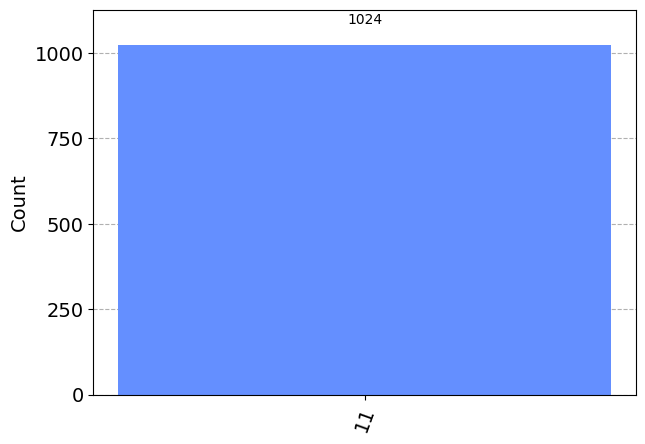

In [18]:
counts = GetCounts(qc)
plot_histogram(counts)

## Application in Teleportation

Consider a system of three qubits, i.e., three subsystems: $q_0$, $q_1$, and $q_2$. 

- Suppose that $q_0$ is initially in a product (a.k.a separable or classical) state $|0\rangle_{q_0}$, i.e., not entangled.
- Suppose that $q_1$ and $q_2$ are initially entangled in the maximally entangled Bell state $|\phi^+ \rangle$.

The global state of the system is, therefore:

$$|\psi\rangle =  |0\rangle_{q_0} \otimes |\phi^+ \rangle = |0\rangle_{q_0} \otimes \frac{1}{\sqrt{2}} (|0\rangle_{q_1} \otimes |0\rangle_{q_2} + |1\rangle_{q_1} \otimes |1\rangle_{q_2}).$$


A Bell measurement on $q_0$ and $q_1$ will maximally entangle these qubits and destroy the previous entanglement between $q_1$, and $q_2$. 

**The goal of the Teleportation Protocol:** Alice wants to teleport an arbitrary single-qubit state $|\psi\rangle = \alpha |0\rangle + \beta |1\rangle$ to Bob.

Steps of the protocol:

1. Alice applies a single-qubit unitary gate $U$ to qubit $q_0$ to prepare the state $|\psi\rangle$.
1. Telamon entangles qubits $q_1$ and $q_2$. He sends $q_1$ to Alice and $q_2$ to Bob.
2. Alice performs a Bell measurement on qubits $q_0$ and $q_1$. This will destroy the entanglement between $q_1$ and $q_2$, but will create entanglement between $q_0$ and $q_1$ by leveraging the previous entanglement between $q_1$ and $q_2$. This is required to establish the quantum correlations necessary to transfer the quantum state $|\psi\rangle$ to Bob.
3. Alice then performs a measurement on qubits $q_0$ and $q_1$, storing the classical results in classical bits $c_0$ and $c_1$, respectively. These bits are sent to Bob.
4. To reconstruct the teleported state, Bob applies one of the four operations from the set {$I_d, X, Z, ZX$} on his qubit $q_2$, depending on the classical information (bits) he receives from Alice. 

## Application in Superdense Coding

# Entanglement Swapping

Consider two entangled pairs of qubits: $(A, B)$ and $(C, D)$. If a Bell-state measurement is performed on B and C, this measurement projects B and C into one of the four Bell states. As a consequence of the Bell-state measurement, the pairs $(A, B)$ and $(C, D)$ lose entanglement, while a new entangled pair $(A, D)$ arises from particles A and D without any direct interaction between them.

Applications:

- Quantum Repeaters for quantum networks: entanglement swapping can extend entanglement over long distances in quantum communication networks such as quantum internet.

Entanglement swapping was used in Hensen et al. 2015 loophole-free experiment to test Bell's inequality. It enabled two spin-like particles (electrons) to become entangled through the exchange of photons.

**Proof:**

We start with two entangled pairs of qubits:

\begin{eqnarray}
(A, B): \ |\psi\rangle_{AB} = \frac{1}{\sqrt{2}} \left( |00\rangle_{AB} + |11\rangle_{AB} \right),
\end{eqnarray}

\begin{eqnarray}
(C, D): \ |\psi\rangle_{CD} = \frac{1}{\sqrt{2}} \left( |00\rangle_{CD} + |11\rangle_{CD} \right).
\end{eqnarray}

The total system state is the tensor product of these two entangled states:

\begin{eqnarray}
|\Psi\rangle_{ABCD} = |\psi\rangle_{AB} \otimes |\psi\rangle_{CD} = \frac{1}{2} \left( |00\rangle_{AB} + |11\rangle_{AB} \right) \otimes \left( |00\rangle_{CD} + |11\rangle_{CD} \right).
\end{eqnarray}

Expanding this expression:

\begin{eqnarray}
|\Psi\rangle_{ABCD} = \frac{1}{2} \Big( |00\rangle_{AB}|00\rangle_{CD} + |00\rangle_{AB}|11\rangle_{CD} + |11\rangle_{AB}|00\rangle_{CD} + |11\rangle_{AB}|11\rangle_{CD} \Big).
\end{eqnarray}

The Bell states for qubits B and C are defined as:

\begin{eqnarray}
|\Phi^\pm\rangle_{BC} = \frac{1}{\sqrt{2}} \left( |00\rangle_{BC} \pm |11\rangle_{BC} \right),
\end{eqnarray}

\begin{eqnarray}
|\Psi^\pm\rangle_{BC} = \frac{1}{\sqrt{2}} \left( |01\rangle_{BC} \pm |10\rangle_{BC} \right).
\end{eqnarray}

Using the completeness relation, the computational bases $|ab\rangle_{BC}$ for two-qubits can be expressed in terms of the Bell states, as follows:

\begin{eqnarray}
|00\rangle_{BC} = \frac{1}{\sqrt{2}} \Big( |\Phi^+\rangle_{BC} + |\Phi^-\rangle_{BC} \Big),
\end{eqnarray}

\begin{eqnarray}
|11\rangle_{BC} = \frac{1}{\sqrt{2}} \Big( |\Phi^+\rangle_{BC} - |\Phi^-\rangle_{BC} \Big),
\end{eqnarray}

\begin{eqnarray}
|01\rangle_{BC} = \frac{1}{\sqrt{2}} \Big( |\Psi^+\rangle_{BC} + |\Psi^-\rangle_{BC} \Big),
\end{eqnarray}

\begin{eqnarray}
|10\rangle_{BC} = \frac{1}{\sqrt{2}} \Big( |\Psi^+\rangle_{BC} - |\Psi^-\rangle_{BC} \Big).
\end{eqnarray}

In [39]:
# Prob. Ampl.:
amp = 1/np.sqrt(2)

# Eigenstates of the Pauli-Z gate (Z-basis):
zero=np.array([[1,0]]) # 2D row-like (bra vector) numpy array representing the classical state <0|.
one=np.array([[0,1]])  # 2D row-like (bra vector) numpy array representing the classical state <1|.

# Tensor Products:
zero_zero = np.kron(zero.T,zero.T)
one_one = np.kron(one.T,one.T)
zero_one = np.kron(zero.T,one.T)
one_zero = np.kron(one.T,zero.T)

# Bell States:
phi_plus = amp * (zero_zero + one_one)
phi_minus = amp * (zero_zero - one_one)
psi_plus = amp * (zero_one + one_zero)
psi_minus = amp * (zero_one - one_zero)

# Checking:
print(
np.allclose(zero_zero, amp * (phi_plus + phi_minus)),
np.allclose(one_one, amp * (phi_plus - phi_minus)),
np.allclose(zero_one, amp * (psi_plus + psi_minus)),
np.allclose(one_zero, amp * (psi_plus - psi_minus))
)

True True True True


Substituting the above expressions into $|\Psi\rangle_{ABCD}$, we rewrite the total state in the Bell basis for qubits $B$ and $C$:

\begin{eqnarray}
|\Psi\rangle_{ABCD} = \frac{1}{2} \sum_{\text{Bell states}} |\text{Bell}\rangle_{BC} \otimes |\psi_{AD}^{(\text{Bell})}\rangle.
\end{eqnarray}

Here, $|\psi_{AD}^{(\text{Bell})}\rangle$ are the resulting states of qubits $A$ and $D$ which depend on the specific Bell state of $B$ and $C$. For example:

- If $B$ and $C$ are measured in $|\Phi^+\rangle_{BC}$ then $A$ and $D$ collapse into $|\Phi^+\rangle_{AD}$.
- If $B$ and $C$ are measured in $|\Phi^-\rangle_{BC}$ then $A$ and $D$ collapse into $|\Phi^-\rangle_{AD}$ and so on.

# Entanglement Monogamy

Entanglement monogamy states that if two quantum systems, $A$ and $B$, are maximally entangled, then neither can share entanglement with a third system, $C$. 

- Monogamy specifically refers to pairwise maximally entangled states.

**Proof:**



## Contrast with the multipartite GHZ entangled state

The Greenberger-Horne-Zeilinger (GHZ) state is a maximally entangled state of three qubits defined by:

$$|GHZ \rangle = \frac{1}{\sqrt2}(|000\rangle + |111\rangle).$$

**Does the multipartite entangled GHZ state violate monogamy?**

It does not violate monogamy because:
- The entanglement involves all three qubits simultaneously rather than pairwise entanglement between two qubits.
- If you trace out one qubit (e.g., qubit C), the remaining two qubits (A and B) are in a separable (non-entangled) state.

$$ Tr_c(\rho_{abc}) =  Tr_c(|\psi_{abc}\rangle \langle \psi_{abc}|) = ...$$

In [36]:
'''GHZ'''

def GHZ():
    qc = QuantumCircuit(3,3) 
    qc.h([0]), qc.cx(0,1), qc.cx(1,2)
    print(Statevector.from_instruction(qc))
    return qc

qc = GHZ()
qc.draw() 

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.70710678+0.j],
            dims=(2, 2, 2))


┌───┐          
q_0: ┤ H ├──■───────
     └───┘┌─┴─┐     
q_1: ─────┤ X ├──■──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘
c: 3/═══════════════

Measurement results: {'111 000': 515, '000 000': 509}


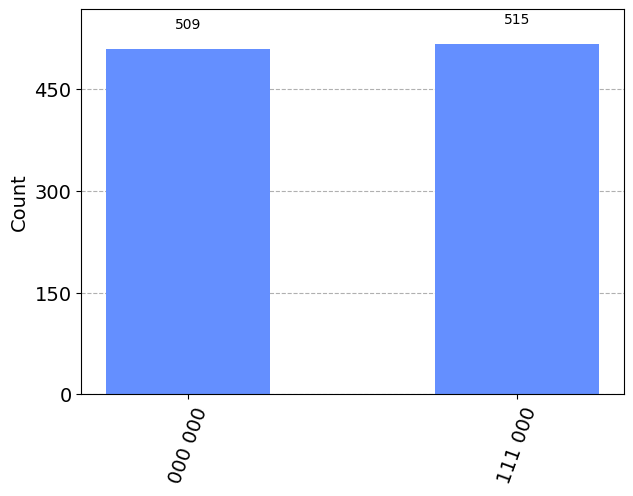

In [37]:
qc.measure_all()                                                  # Measuring all qubits. A quantum computer always measures in the computational basis.
backend = Aer.get_backend('qasm_simulator')                       # Define the Backend for the simulator.
counts = execute(qc, backend, shots = 1024).result().get_counts() # Run the simulation and get the counts.
print("Measurement results:", counts)                             # 
plot_histogram(counts)                                            # Plot a histogram of outcomes and corresponding probabilities.

### GHZ-like State

A GHZ-like state is the following:

$$|\psi \rangle = \frac{1}{\sqrt2}(|011\rangle - |100\rangle).$$

In [38]:
def GHZ_Like():
    qc = QuantumCircuit(3,3) 
    qc.h([0]), qc.x(2), qc.cx(0,1), qc.cx(1,2), qc.z(2)
    print(Statevector.from_instruction(qc))
    return qc

qc = GHZ_Like()
qc.draw() 

Statevector([ 0.        +0.j,  0.        +0.j,  0.        +0.j,
              0.70710678+0.j, -0.70710678+0.j,  0.        +0.j,
              0.        +0.j,  0.        +0.j],
            dims=(2, 2, 2))


┌───┐               
q_0: ┤ H ├──■────────────
     └───┘┌─┴─┐          
q_1: ─────┤ X ├──■───────
     ┌───┐└───┘┌─┴─┐┌───┐
q_2: ┤ X ├─────┤ X ├┤ Z ├
     └───┘     └───┘└───┘
c: 3/════════════════════

In [39]:
from qiskit.opflow import One, Zero
import math

ghz_state=(1/math.sqrt(2))*((Zero^One^One)-(One^Zero^Zero))
ghz_state.to_matrix()

array([ 0.        +0.j,  0.        +0.j,  0.        +0.j,  0.70710678+0.j,
       -0.70710678+0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j])

Measurement results: {'100 000': 535, '011 000': 489}


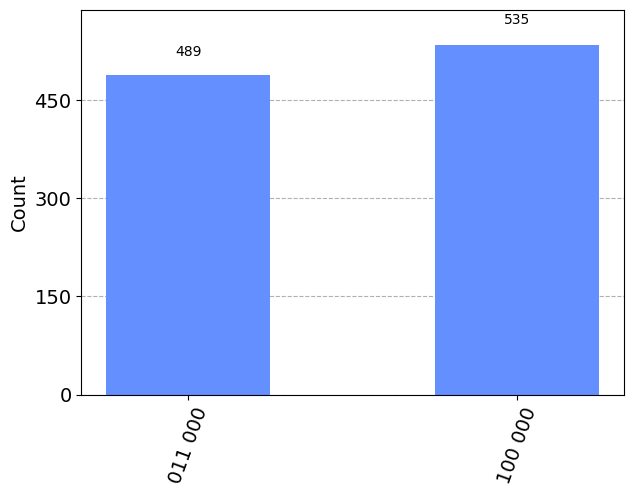

In [40]:
qc.measure_all()                                                  # Measuring all qubits. A quantum computer always measures in the computational basis.
backend = Aer.get_backend('qasm_simulator')                       # Define the Backend for the simulator.
counts = execute(qc, backend, shots = 1024).result().get_counts() # Run the simulation and get the counts.
print("Measurement results:", counts)                             # 
plot_histogram(counts)                                            # Plot a histogram of outcomes and corresponding probabilities.

## Contrast with the multipartite W entangled state

\begin{align}
|W\rangle_{3qb} &\doteq \frac{1}{\sqrt{3}} \left ( |001\rangle +  |010\rangle + |100\rangle \right).
\end{align} 

## Connection with the no-cloning theorem and QKD

The no-cloning theorem states that it is impossible to create an exact copy of an arbitrary unknown quantum state.

If cloning were allowed, a system A could "clone" its quantum state and distribute entanglement freely to multiple systems, violating the principle of monogamy.

# DI-QKD vs MDI-QKD

- DI-QKD:
    - Is Fully device-independent. 
    - Input states are entangled. Relies on Bell inequality violations.

</br>

- MDI-QKD:
    - There is trust in the source, but no trust in the measurement device.
    - Input states are separable and not entangled. Uses Bell state measurements.

# &nbsp; <a href="#"><img valign="middle" height="45px" src="https://img.icons8.com/book" width="45" hspace="0px" vspace="0px"></a> References<a name="ref" />

\[1] Nielsen MA, Chuang IL. 2010. Quantum Computation and Quantum Information. New York: [Cambridge Univ. Press.](https://doi.org/10.1017/CBO9780511976667) 10th Anniv. Ed.<a name="ref1" />  
- Corollary 4.2, pg. 176: Gate decomposition.
- Theorem 4.3, pg. 207: Trotter formula. 
- Chapter 4.7.2, pg. 206: The quantum simulation algorithm.

[2] Wolf, R. (2021). Quantum key distribution: An introduction with exercises. Publisher. https://doi.org/10.1007/978-3-030-73991-1

[3] [My educational/survey paper](https://arxiv.org/abs/2109.06444).

[4] Below videos from Sabine Hossenfelder's YouTube channel.
- [Understanding Quantum Mechanics #1: It’s not about discreteness](https://www.youtube.com/watch?v=XJSfgE9LUJw)
- [Understanding Quantum Mechanics #2: Superposition and Entanglement](https://www.youtube.com/watch?v=j6Mw3_tOcNI)
- [Understanding Quantum Mechanics #3: Non-locality](https://www.youtube.com/watch?v=XL9wWeEmQvo)
- [Understanding Quantum Mechanics #4: It's not so difficult!](https://www.youtube.com/watch?v=ctXDXABJRtg)